In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None ##wagi
        self.intercept_ = None ##bias
        self.r2score_ = None ##miara jakości
        
    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X] ##doklejenie kolumny jedynek to dancych treningowych 
   
        ## w = (X^T @ X)^(-1) @ X^(-1) @ y
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y) 
        ## wyodrębnienie kolumny biasu
        self.intercept_ = self.coefficients_[0] 
        ## X @ w
        y_pred = X_b.dot(self.coefficients_) 
        # R² = 1 - (błąd kwadratowy / wariancja)
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred
        
    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients_)

Simple LR Coefficients: [1.06666667 1.00606061]
R² Score: 0.94


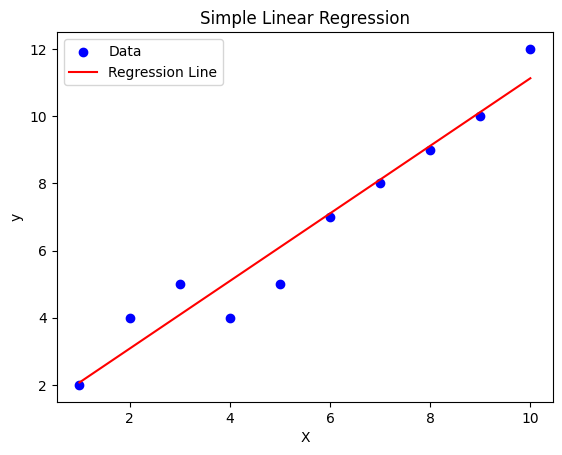

In [25]:
X_simple = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y_simple = np.array([2,4,5,4,5,7,8,9,10,12])

slr = SimpleLinearRegression()
slr.fit(X_simple, y_simple)


print(f"R² Score: {slr.r2score_:.2f}")

plt.scatter(X_simple, y_simple, color='blue', label='Data')
plt.plot(X_simple, slr.y_pred_, color='red', label='Regression Line')
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [20]:
import numpy as np

class LinearRegressionGD:
    def __init__(self, lr=0.01, n_iters=1000, tol=1e-6):
        self.lr = lr
        self.n_iters = n_iters
        self.tol = tol
        self.weights = None
        self.bias = None
        self.r2score_ = None
        self.loss_history_ = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # inicjalizacja
        self.weights = np.zeros(n_features)
        self.bias = 0

        prev_loss = float('inf')

        for _ in range(self.n_iters):

            # 1. predykcja
            y_pred = np.dot(X, self.weights) + self.bias

            # 2. gradienty
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # 3. update parametrów
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # 4. loss (MSE)
            loss = np.mean((y - y_pred) ** 2)
            self.loss_history_.append(loss)

            # 5. stop condition
            if abs(prev_loss - loss) < self.tol:
                break

            prev_loss = loss

        # 6. R² po treningu
        self.r2score_ = self.score(X, y)
        self.y_pred_ = y_pred

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

R² Score: 0.94


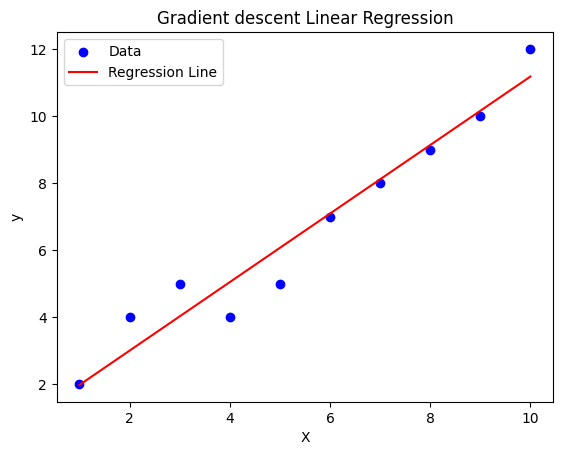

In [29]:
X_simple = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y_simple = np.array([2,4,5,4,5,7,8,9,10,12])

slr = LinearRegressionGD()
slr.fit(X_simple, y_simple)


print(f"R² Score: {slr.r2score_:.2f}")

plt.scatter(X_simple, y_simple, color='blue', label='Data')
plt.plot(X_simple, slr.y_pred_, color='red', label='Regression Line')
plt.title("Gradient descent Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [17]:
np.random.seed(0)
X1 = np.random.randint(1, 11, 15)
X2 = np.random.randint(1, 11, 15)
X_multi = np.column_stack((X1, X2))
y_multi = 1 + 2*X1 + 3*X2 + np.random.randn(15)*2

mlr = LinearRegressionGD()
mlr.fit(X_multi, y_multi)
print(f"Multiple LR Coefficients: {mlr.coefficients_}")
print(f"R² Score: {mlr.r2score_:.2f}")

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_multi[:,0], X_multi[:,1], y_multi, color='blue', label='Data')

x1_surf, x2_surf = np.meshgrid(
    np.linspace(X_multi[:,0].min(), X_multi[:,0].max(), 10),
    np.linspace(X_multi[:,1].min(), X_multi[:,1].max(), 10)
)

pred_surf = mlr.predict(np.c_[x1_surf.ravel(), x2_surf.ravel()]).reshape(x1_surf.shape)

ax.plot_surface(x1_surf, x2_surf, pred_surf, color='red', alpha=0.5, rstride=1, cstride=1)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title("Multiple Linear Regression with Regression Plane")
ax.legend()
plt.show()

AttributeError: 'LinearRegressionGD' object has no attribute 'coefficients_'